# MVSTGCN Eval + Fast Calibration (Temperature Scaling) 2022
This notebook:
1) Reads weekly predictions + labeled ground truth from S3
2) Joins on (ts15_utc, sourceelementkey)
3) Removes duplicates safely
4) Computes metrics + curves + calibration diagram
5) Fits temperature scaling **on a sample** with **few Ts** and evaluates pre/post

Just edit the CONFIG cell and run all.

In [1]:
import io, gzip
from urllib.parse import urlparse

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# CONFIG (EDIT ME)
S3_ROOT = "s3://smart-park-seattle/parking_v2/"   # root prefix
YEAR = 2022
TARGET = "y_15"   # "y_15" or "y_30"

# Weeks to evaluate (YYYY-MM-DD strings)
TEST_WEEKS = [
    "2022-11-07","2022-11-14","2022-11-21","2022-11-28",
    "2022-12-05","2022-12-12","2022-12-19","2022-12-26",
]

# Paths relative to S3_ROOT
PRED_PREFIX = "preds/final/year={YEAR}/target={TARGET}/"      # contains week=.../pred.csv.gz
LABEL_PREFIX = "labeled/year={YEAR}/"                         # contains week=.../data.csv.gz  (change if your labeled path differs)

PRED_FILE = "pred.csv.gz"
LABEL_FILE = "data.csv.gz"

# Dedup policy: keep last row per (ts15_utc, sourceelementkey)
DEDUP_KEEP = "last"  # "last" or "first"

# Temperature scaling fit settings
FIT_SAMPLE_N = 200_000   # sample size used for grid search (fit only)
TS_GRID = list(np.linspace(0.8, 4.0, 15))   # fewer Ts

# Thresholds for table
THRESHOLDS = [0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85]

# Safety
EPS = 1e-6
RNG_SEED = 0


In [3]:
def parse_s3_uri(s3_uri: str):
    if not s3_uri.startswith("s3://"):
        raise ValueError("S3 uri must start with s3://")
    u = urlparse(s3_uri)
    bucket = u.netloc
    prefix = u.path.lstrip("/")
    if prefix and not prefix.endswith("/"):
        prefix += "/"
    return bucket, prefix

def s3_client():
    return boto3.client("s3")

def s3_read_csv_gz(s3, bucket: str, key: str, usecols=None) -> pd.DataFrame:
    obj = s3.get_object(Bucket=bucket, Key=key)
    raw = obj["Body"].read()
    with gzip.GzipFile(fileobj=io.BytesIO(raw), mode="rb") as f:
        return pd.read_csv(f, low_memory=False, usecols=usecols)

def safe_clip_prob(p, eps=EPS):
    p = np.asarray(p, dtype=np.float64)
    return np.clip(p, eps, 1.0-eps)

def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    return 1.0/(1.0+np.exp(-z))

def log_loss(y, p, eps=EPS):
    y = np.asarray(y, dtype=np.float64)
    p = safe_clip_prob(p, eps)
    return float(-np.mean(y*np.log(p) + (1.0-y)*np.log(1.0-p)))

def brier(y, p):
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    return float(np.mean((p-y)**2))

def _pred_prob_col(df: pd.DataFrame) -> str:
    # Accept several naming conventions
    for c in ["pred","p15","p30","p","prob","probability"]:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find prob column in pred df. Columns: {list(df.columns)[:30]}")

def _label_cols_for_target(target: str):
    if target == "y_15":
        return ("y_15", "y15")
    if target == "y_30":
        return ("y_30", "y30")
    raise ValueError("TARGET must be y_15 or y_30")

def read_pred_week(s3, bucket: str, root_prefix: str, week: str) -> pd.DataFrame:
    pred_prefix = PRED_PREFIX.format(YEAR=YEAR, TARGET=TARGET)
    key = f"{root_prefix}{pred_prefix}week={week}/{PRED_FILE}"
    df = s3_read_csv_gz(s3, bucket, key).copy()

    prob_col = _pred_prob_col(df)
    df = df.rename(columns={prob_col: "pred"})

    logit_col = "logit15" if TARGET == "y_15" else "logit30"
    has_logit = logit_col in df.columns
    if has_logit:
        df[logit_col] = pd.to_numeric(df[logit_col], errors="coerce")  # do NOT drop rows

    df["ts15_utc"] = pd.to_datetime(df["ts15_utc"], utc=True, errors="coerce")
    df["sourceelementkey"] = pd.to_numeric(df["sourceelementkey"], errors="coerce").astype("Int64")
    df["pred"] = pd.to_numeric(df["pred"], errors="coerce")

    df = df.dropna(subset=["ts15_utc","sourceelementkey","pred"]).copy()
    df["pred"] = df["pred"].clip(EPS, 1.0-EPS)

    cols = ["ts15_utc","sourceelementkey","pred"]
    if has_logit:
        cols.append(logit_col)
    return df[cols]

def read_label_week(s3, bucket: str, root_prefix: str, week: str) -> pd.DataFrame:
    # Adjust LABEL_PREFIX if your labeled path differs.
    label_prefix = LABEL_PREFIX.format(YEAR=YEAR)
    key = f"{root_prefix}{label_prefix}week={week}/{LABEL_FILE}"
    df = s3_read_csv_gz(s3, bucket, key).copy()

    y_candidates = _label_cols_for_target(TARGET)
    y_col = None
    for c in y_candidates:
        if c in df.columns:
            y_col = c
            break
    if y_col is None:
        raise KeyError(f"Could not find y column for {TARGET}. Columns: {list(df.columns)[:30]}")

    df["ts15_utc"] = pd.to_datetime(df["ts15_utc"], utc=True, errors="coerce")
    df["sourceelementkey"] = pd.to_numeric(df["sourceelementkey"], errors="coerce").astype("Int64")
    df["y"] = pd.to_numeric(df[y_col], errors="coerce")

    df = df.dropna(subset=["ts15_utc","sourceelementkey","y"]).copy()
    df["y"] = df["y"].astype(np.int8)
    return df[["ts15_utc","sourceelementkey","y"]]

def dedup_ts_node(df: pd.DataFrame, keep: str = "last") -> pd.DataFrame:
    if keep not in ("last","first"):
        raise ValueError("keep must be 'last' or 'first'")
    df = df.sort_values(["ts15_utc","sourceelementkey"])
    return df.drop_duplicates(["ts15_utc","sourceelementkey"], keep=keep).reset_index(drop=True)


In [4]:
import json
from parking_processing.utils.s3 import s3_client, parse_s3_uri, s3_get_text

s3 = s3_client()
bucket, root_prefix = parse_s3_uri(S3_ROOT)

splits = json.loads(s3_get_text(s3, bucket, f"{root_prefix}splits/year={YEAR}/splits.json"))

# 원하는 것만
TRAIN_WEEKS = splits["train_weeks"]
VAL_WEEKS   = splits["val_weeks"]
TEST_WEEKS  = splits["test_weeks"]

print("n_train", len(TRAIN_WEEKS), "n_val", len(VAL_WEEKS), "n_test", len(TEST_WEEKS))
print("test first/last:", TEST_WEEKS[0], TEST_WEEKS[-1])

n_train 40 n_val 4 n_test 8
test first/last: 2022-11-07 2022-12-26


In [5]:
# Load & join all weeks
s3 = s3_client()
bucket, root_prefix = parse_s3_uri(S3_ROOT)

all_rows = []
week_rows = []

for week in TEST_WEEKS:
    pred = read_pred_week(s3, bucket, root_prefix, week)
    lab  = read_label_week(s3, bucket, root_prefix, week)

    # dedup BEFORE join (prevents bias + speeds up merge)
    pred = dedup_ts_node(pred, keep=DEDUP_KEEP)
    lab  = dedup_ts_node(lab,  keep=DEDUP_KEEP)

    joined = pred.merge(lab, on=["ts15_utc","sourceelementkey"], how="inner")

    # week stats
    week_rows.append({
        "week": week,
        "N_join": len(joined),
        "pred_ts": joined["ts15_utc"].nunique(),
        "pred_nodes": joined["sourceelementkey"].nunique(),
    })

    all_rows.append(joined)

all_eval = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
week_df = pd.DataFrame(week_rows)

print("weeks:", TEST_WEEKS)
print("all_eval shape:", all_eval.shape)
display(week_df.head())


weeks: ['2022-11-07', '2022-11-14', '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12', '2022-12-19', '2022-12-26']
all_eval shape: (2761175, 5)


,week,N_join,pred_ts,pred_nodes
0,2022-11-07,324350,278,1466
1,2022-11-14,389251,334,1462
2,2022-11-21,320754,278,1462
3,2022-11-28,258572,270,1460
4,2022-12-05,392157,334,1465


In [6]:
# Basic sanity
assert len(all_eval) > 0, "No joined rows. Check S3 paths / weeks / prefixes."

dup_count = all_eval.duplicated(["ts15_utc","sourceelementkey"]).sum()
print("duplicates in all_eval(ts,node):", int(dup_count))

y = all_eval["y"].to_numpy(dtype=np.int8)
p = all_eval["pred"].to_numpy(dtype=float)
p = safe_clip_prob(p)

pos_rate = float(y.mean())
print("N:", len(y), "pos_rate:", pos_rate, "p_range:", (float(p.min()), float(p.max())))


duplicates in all_eval(ts,node): 0
N: 2761175 pos_rate: 0.5738803226887105 p_range: (1e-06, 0.999999)


GLOBAL
  AUC_ROC : 0.9808802356968994
  PR_AUC  : 0.9855966405730383
  LogLoss : 0.1828881725802686
  Brier   : 0.053420671589877934


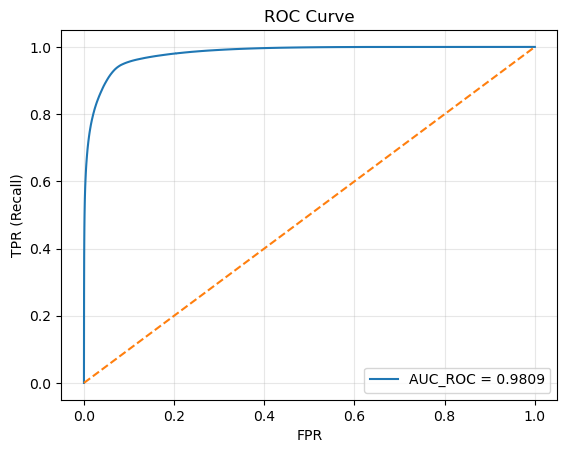

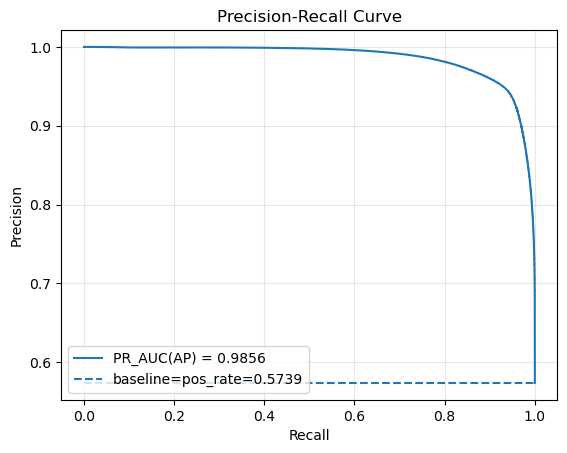

,thr,precision,recall,f1,TP,FP,TN,FN,FPR,FNR
0,0.50,0.938721,0.947014,0.942849,1500624,97960,1078631,83960,0.083257,0.052986
1,0.55,0.945934,0.937226,0.941560,1485113,84884,1091707,99471,0.072144,0.062774
2,0.60,0.952193,0.923690,0.937725,1463665,73486,1103105,120919,0.062457,0.076310
3,0.65,0.958769,0.904333,0.930756,1432991,61624,1114967,151593,0.052375,0.095667
4,0.70,0.966012,0.877431,0.919593,1390363,48919,1127672,194221,0.041577,0.122569
5,0.75,0.973725,0.842836,0.903565,1335545,36038,1140553,249039,0.030629,0.157164
6,0.80,0.980775,0.802768,0.882889,1272054,24934,1151657,312530,0.021192,0.197232
7,0.85,0.986429,0.758039,0.857283,1201176,16526,1160065,383408,0.014046,0.241961


In [7]:
# Metrics + curves + threshold table
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

auc = float(roc_auc_score(y, p))
ap  = float(average_precision_score(y, p))
ll  = log_loss(y, p)
br  = brier(y, p)

print("GLOBAL")
print("  AUC_ROC :", auc)
print("  PR_AUC  :", ap)
print("  LogLoss :", ll)
print("  Brier   :", br)

# ROC
fpr, tpr, _ = roc_curve(y, p)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC_ROC = {auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR (Recall)"); plt.title("ROC Curve")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

# PR
prec, rec, _ = precision_recall_curve(y, p)
plt.figure()
plt.plot(rec, prec, label=f"PR_AUC(AP) = {ap:.4f}")
plt.hlines(pos_rate, 0, 1, linestyles="--", label=f"baseline=pos_rate={pos_rate:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

# Threshold table
rows = []
for thr in THRESHOLDS:
    pred_pos = (p >= thr).astype(np.int8)
    TP = int(((pred_pos==1) & (y==1)).sum())
    FP = int(((pred_pos==1) & (y==0)).sum())
    TN = int(((pred_pos==0) & (y==0)).sum())
    FN = int(((pred_pos==0) & (y==1)).sum())

    precision = TP / (TP+FP+1e-12)
    recall    = TP / (TP+FN+1e-12)
    f1        = 2*precision*recall/(precision+recall+1e-12)

    FPR = FP / (FP+TN+1e-12)
    FNR = FN / (FN+TP+1e-12)

    rows.append({
        "thr": thr,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "FPR": FPR, "FNR": FNR
    })

thr_df = pd.DataFrame(rows)
display(thr_df)


UNCALIBRATED  ECE: 0.0338081810378354 MCE: 0.10567284016030284


,bin,p_min,p_max,p_mean,y_rate,count
0,0,0.0,0.1,0.021311,0.008404,722882
1,1,0.1,0.2,0.147035,0.080880,167074
2,2,0.2,0.3,0.247546,0.157966,120431
3,3,0.3,0.4,0.346880,0.241207,89019
4,4,0.4,0.5,0.447971,0.377874,63185
5,5,0.5,0.6,0.552357,0.601615,61433
6,6,0.6,0.7,0.654288,0.748981,97869
7,7,0.7,0.8,0.751580,0.831441,142294
8,8,0.8,0.9,0.854363,0.915299,181461
9,9,0.9,1.0,0.979209,0.991426,1115527


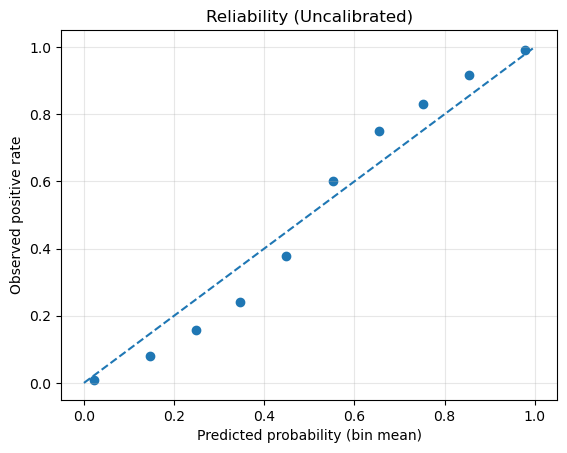

In [8]:
# Reliability (calibration) bins + ECE/MCE
def calibration_bins(y, p, n_bins=10):
    y = np.asarray(y, dtype=np.float64)
    p = safe_clip_prob(p)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    b = np.minimum(np.digitize(p, edges, right=False) - 1, n_bins - 1)
    b = np.maximum(b, 0)

    rows = []
    for i in range(n_bins):
        m = (b == i)
        cnt = int(m.sum())
        if cnt == 0:
            rows.append((i, edges[i], edges[i+1], np.nan, np.nan, 0))
        else:
            rows.append((i, edges[i], edges[i+1], float(p[m].mean()), float(y[m].mean()), cnt))
    return pd.DataFrame(rows, columns=["bin","p_min","p_max","p_mean","y_rate","count"])

def ece_mce(df_bins):
    df = df_bins[df_bins["count"]>0].copy()
    N = df["count"].sum()
    gap = np.abs(df["y_rate"] - df["p_mean"])
    ece = float(np.sum((df["count"]/N)*gap))
    mce = float(np.max(gap)) if len(gap) else 0.0
    return ece, mce

bins_raw = calibration_bins(y, p, n_bins=10)
ece_raw, mce_raw = ece_mce(bins_raw)
print("UNCALIBRATED  ECE:", ece_raw, "MCE:", mce_raw)
display(bins_raw)

plt.figure()
plt.plot([0,1],[0,1],"--")
plt.scatter(bins_raw["p_mean"], bins_raw["y_rate"])
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Observed positive rate")
plt.title("Reliability (Uncalibrated)")
plt.grid(True, alpha=0.3)
plt.show()


sigmoid(logit) vs pred: max_diff= 1.0000000000287557e-06 mean_diff= 6.23973125642683e-08
T grid: [0.8, 1.0285714285714287, 1.2571428571428571, 1.4857142857142858, 1.7142857142857144, 1.942857142857143, 2.1714285714285717, 2.4000000000000004, 2.628571428571429, 2.8571428571428577, 3.0857142857142863, 3.314285714285715, 3.5428571428571427, 3.7714285714285714, 4.0]
logloss(T) on sample: [0.17274745489718124, 0.1826818694813893, 0.19769775911827647, 0.21462783660761015, 0.2320270157862635, 0.24918450314865767, 0.26574582906133126, 0.2815430770255249, 0.2965100977176459, 0.3106371120516332, 0.3239452879003452, 0.33647210728931676, 0.34826282636029604, 0.35936548256945877, 0.3698280097935203]
BEST T: 0.8 best sample logloss: 0.17274745489718124

PRE/POST (on all finite-logit rows)
  LogLoss raw -> cal: 0.1828881725802686 -> 0.1748530008380733
  Brier   raw -> cal: 0.053420671589877934 -> 0.05170641867489712
CALIBRATED    ECE: 0.013373088377572421 MCE: 0.07536497516711221


,bin,p_min,p_max,p_mean,y_rate,count
0,0,0.0,0.1,0.017843,0.014343,809044
1,1,0.1,0.2,0.145718,0.116284,143055
2,2,0.2,0.3,0.247153,0.191615,94810
3,3,0.3,0.4,0.346877,0.271512,66358
4,4,0.4,0.5,0.448529,0.396095,49324
5,5,0.5,0.6,0.551556,0.580113,47639
6,6,0.6,0.7,0.654057,0.718713,69694
7,7,0.7,0.8,0.753491,0.797233,112469
8,8,0.8,0.9,0.852646,0.875360,156098
9,9,0.9,1.0,0.984506,0.986730,1212684


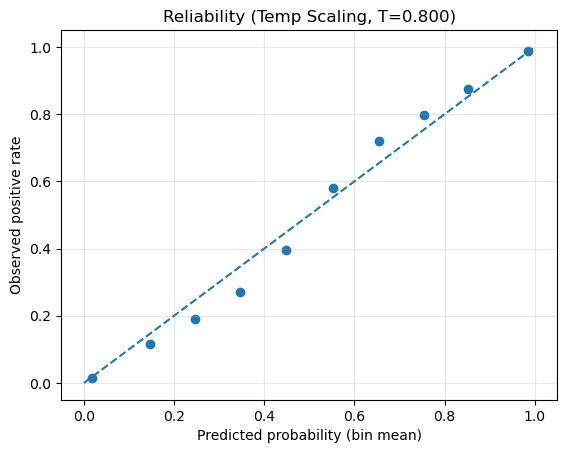

,stage,LogLoss,Brier,ECE,MCE,T
0,raw,0.182888,0.053421,0.033808,0.105673,NaN
1,cal_T,0.174853,0.051706,0.013373,0.075365,0.8


In [9]:
# Temperature scaling (FAST): fit on a sample with a small T grid, apply to all

logit_col = "logit15" if TARGET == "y_15" else "logit30"
if logit_col not in all_eval.columns:
    raise KeyError(f"logit column not found in all_eval: {logit_col}. Ensure your final preds include logits and read_pred_week keeps it.")

z_all = pd.to_numeric(all_eval[logit_col], errors="coerce").to_numpy(dtype=float)
mask = np.isfinite(z_all) & np.isfinite(p) & np.isfinite(y)
z_all = z_all[mask]
y_all = y[mask]
p_all = p[mask]

# Optional consistency check
p_from_logit = sigmoid(z_all)
max_diff = float(np.max(np.abs(p_from_logit - p_all)))
mean_diff = float(np.mean(np.abs(p_from_logit - p_all)))
print("sigmoid(logit) vs pred: max_diff=", max_diff, "mean_diff=", mean_diff)

# sample indices for fitting T
rng = np.random.default_rng(RNG_SEED)
N = len(y_all)
m = min(FIT_SAMPLE_N, N)
idx = rng.choice(N, size=m, replace=False)

Ts = np.array(TS_GRID, dtype=float)

def ll_for_T(T):
    pT = safe_clip_prob(sigmoid(z_all[idx] / T))
    return log_loss(y_all[idx], pT)

lls = np.array([ll_for_T(T) for T in Ts])
best_i = int(np.argmin(lls))
best_T = float(Ts[best_i])

print("T grid:", Ts.tolist())
print("logloss(T) on sample:", lls.tolist())
print("BEST T:", best_T, "best sample logloss:", float(lls[best_i]))

# Apply to full
p_cal = safe_clip_prob(sigmoid(z_all / best_T))

# Pre/Post metrics
ll_raw = log_loss(y_all, p_all)
br_raw = brier(y_all, p_all)
ll_cal = log_loss(y_all, p_cal)
br_cal = brier(y_all, p_cal)

print("\nPRE/POST (on all finite-logit rows)")
print("  LogLoss raw -> cal:", ll_raw, "->", ll_cal)
print("  Brier   raw -> cal:", br_raw, "->", br_cal)

bins_cal = calibration_bins(y_all, p_cal, n_bins=10)
ece_cal, mce_cal = ece_mce(bins_cal)
print("CALIBRATED    ECE:", ece_cal, "MCE:", mce_cal)
display(bins_cal)

plt.figure()
plt.plot([0,1],[0,1],"--")
plt.scatter(bins_cal["p_mean"], bins_cal["y_rate"])
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Observed positive rate")
plt.title(f"Reliability (Temp Scaling, T={best_T:.3f})")
plt.grid(True, alpha=0.3)
plt.show()

summary = pd.DataFrame([
    {"stage":"raw", "LogLoss": ll_raw, "Brier": br_raw, "ECE": ece_raw, "MCE": mce_raw},
    {"stage":"cal_T", "LogLoss": ll_cal, "Brier": br_cal, "ECE": ece_cal, "MCE": mce_cal, "T": best_T},
])
display(summary)


sigmoid(logit) vs pred: max_diff= 1.0000000000287557e-06 mean_diff= 6.23973125642683e-08
T grid: [0.8, 1.0285714285714287, 1.2571428571428571, 1.4857142857142858, 1.7142857142857144, 1.942857142857143, 2.1714285714285717, 2.4000000000000004, 2.628571428571429, 2.8571428571428577, 3.0857142857142863, 3.314285714285715, 3.5428571428571427, 3.7714285714285714, 4.0]
logloss(T) on sample: [0.17274745489718124, 0.1826818694813893, 0.19769775911827647, 0.21462783660761015, 0.2320270157862635, 0.24918450314865767, 0.26574582906133126, 0.2815430770255249, 0.2965100977176459, 0.3106371120516332, 0.3239452879003452, 0.33647210728931676, 0.34826282636029604, 0.35936548256945877, 0.3698280097935203]
BEST T: 0.8 best sample logloss: 0.17274745489718124

PRE/POST (on all finite-logit rows)
  LogLoss raw -> cal: 0.1828881725802686 -> 0.1748530008380733
  Brier   raw -> cal: 0.053420671589877934 -> 0.05170641867489712
CALIBRATED    ECE: 0.013373088377572421 MCE: 0.07536497516711221


,bin,p_min,p_max,p_mean,y_rate,count
0,0,0.0,0.1,0.017843,0.014343,809044
1,1,0.1,0.2,0.145718,0.116284,143055
2,2,0.2,0.3,0.247153,0.191615,94810
3,3,0.3,0.4,0.346877,0.271512,66358
4,4,0.4,0.5,0.448529,0.396095,49324
5,5,0.5,0.6,0.551556,0.580113,47639
6,6,0.6,0.7,0.654057,0.718713,69694
7,7,0.7,0.8,0.753491,0.797233,112469
8,8,0.8,0.9,0.852646,0.875360,156098
9,9,0.9,1.0,0.984506,0.986730,1212684


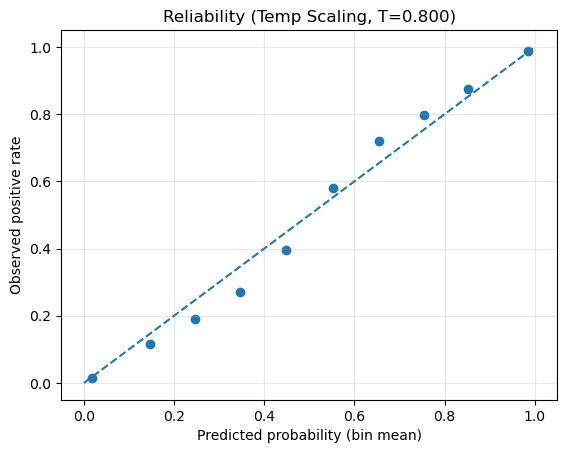

,stage,LogLoss,Brier,ECE,MCE,T
0,raw,0.182888,0.053421,0.033808,0.105673,NaN
1,cal_T,0.174853,0.051706,0.013373,0.075365,0.8


In [10]:
# Temperature scaling (FAST): fit on a sample with a small T grid, apply to all

logit_col = "logit15" if TARGET == "y_15" else "logit30"
if logit_col not in all_eval.columns:
    raise KeyError(f"logit column not found in all_eval: {logit_col}. Ensure your final preds include logits and read_pred_week keeps it.")

z_all = pd.to_numeric(all_eval[logit_col], errors="coerce").to_numpy(dtype=float)
mask = np.isfinite(z_all) & np.isfinite(p) & np.isfinite(y)
z_all = z_all[mask]
y_all = y[mask]
p_all = p[mask]

# Optional consistency check
p_from_logit = sigmoid(z_all)
max_diff = float(np.max(np.abs(p_from_logit - p_all)))
mean_diff = float(np.mean(np.abs(p_from_logit - p_all)))
print("sigmoid(logit) vs pred: max_diff=", max_diff, "mean_diff=", mean_diff)

# sample indices for fitting T
rng = np.random.default_rng(RNG_SEED)
N = len(y_all)
m = min(FIT_SAMPLE_N, N)
idx = rng.choice(N, size=m, replace=False)

Ts = np.array(TS_GRID, dtype=float)

def ll_for_T(T):
    pT = safe_clip_prob(sigmoid(z_all[idx] / T))
    return log_loss(y_all[idx], pT)

lls = np.array([ll_for_T(T) for T in Ts])
best_i = int(np.argmin(lls))
best_T = float(Ts[best_i])

print("T grid:", Ts.tolist())
print("logloss(T) on sample:", lls.tolist())
print("BEST T:", best_T, "best sample logloss:", float(lls[best_i]))

# Apply to full
p_cal = safe_clip_prob(sigmoid(z_all / best_T))

# Pre/Post metrics
ll_raw = log_loss(y_all, p_all)
br_raw = brier(y_all, p_all)
ll_cal = log_loss(y_all, p_cal)
br_cal = brier(y_all, p_cal)

print("\nPRE/POST (on all finite-logit rows)")
print("  LogLoss raw -> cal:", ll_raw, "->", ll_cal)
print("  Brier   raw -> cal:", br_raw, "->", br_cal)

bins_cal = calibration_bins(y_all, p_cal, n_bins=10)
ece_cal, mce_cal = ece_mce(bins_cal)
print("CALIBRATED    ECE:", ece_cal, "MCE:", mce_cal)
display(bins_cal)

plt.figure()
plt.plot([0,1],[0,1],"--")
plt.scatter(bins_cal["p_mean"], bins_cal["y_rate"])
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Observed positive rate")
plt.title(f"Reliability (Temp Scaling, T={best_T:.3f})")
plt.grid(True, alpha=0.3)
plt.show()

summary = pd.DataFrame([
    {"stage":"raw", "LogLoss": ll_raw, "Brier": br_raw, "ECE": ece_raw, "MCE": mce_raw},
    {"stage":"cal_T", "LogLoss": ll_cal, "Brier": br_cal, "ECE": ece_cal, "MCE": mce_cal, "T": best_T},
])
display(summary)


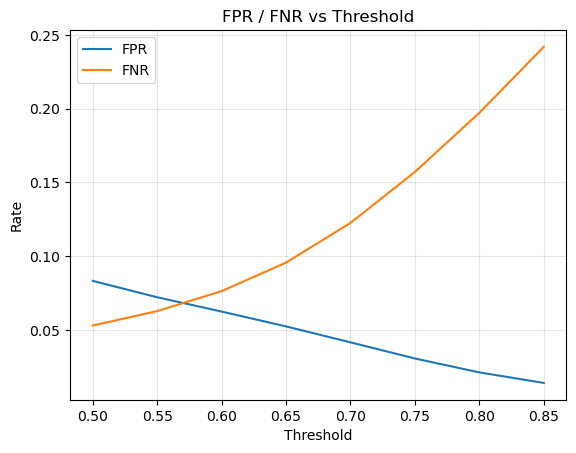

Closest FPR≈FNR threshold: 0.55 FPR: 0.07214401605995627 FNR: 0.06277420445997182


In [12]:
plt.figure()
plt.plot(d["thr"], d["FPR"], label="FPR")
plt.plot(d["thr"], d["FNR"], label="FNR")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("FPR / FNR vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_bal = d.loc[(d["FPR"] - d["FNR"]).abs().idxmin()]
print("Closest FPR≈FNR threshold:", float(best_bal["thr"]),
      "FPR:", float(best_bal["FPR"]), "FNR:", float(best_bal["FNR"]))